# Determinant by divide and conquer

Implementation in [`determinant.py`](determinant.py). Split the matrix into four
blocks and the determinant of the whole follows from the determinant of one
block and a smaller determinant:

    det(M) = det(D*a - C @ adj(A) @ B) / a^(k-1),   a = det(A)

Nothing here calls `numpy.linalg.det`. The earlier version did, inside the
cofactor loop, 112 times for a single 16x16 matrix, which quietly made "from
scratch" false in the one place it mattered.

This notebook used to be named for a complexity bound its own text disowned. No
bound is claimed now, and the timing below shows why one would be hard to
defend.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.5, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
from determinant import determinant, cofactor_matrix, SingularLeadingBlock

## It agrees with NumPy

In [2]:
rng = np.random.default_rng(1)
sizes = [2, 3, 4, 5, 6, 8, 10, 12, 16]
errors, seconds = [], []
for n in sizes:
    M = rng.random((n, n))
    start = time.perf_counter()
    mine = determinant(M)
    seconds.append(time.perf_counter() - start)
    errors.append(abs(mine - np.linalg.det(M)) / abs(np.linalg.det(M)))
    print(f"n={n:>3}  mine {mine:>14.6e}   numpy {np.linalg.det(M):>14.6e}   "
          f"rel {errors[-1]:.1e}   {seconds[-1]*1000:7.1f} ms")

n=  2  mine   3.485208e-01   numpy   3.485208e-01   rel 1.6e-16       0.0 ms
n=  3  mine  -1.569486e-01   numpy  -1.569486e-01   rel 1.8e-16       2.9 ms
n=  4  mine  -1.325598e-01   numpy  -1.325598e-01   rel 4.2e-16       0.1 ms
n=  5  mine  -2.317689e-01   numpy  -2.317689e-01   rel 4.8e-16       0.3 ms
n=  6  mine   8.442519e-02   numpy   8.442519e-02   rel 6.6e-16       0.4 ms
n=  8  mine  -2.626216e-02   numpy  -2.626216e-02   rel 6.6e-16       1.4 ms
n= 10  mine  -1.130312e-02   numpy  -1.130312e-02   rel 6.1e-16       2.3 ms
n= 12  mine   4.213513e-03   numpy   4.213513e-03   rel 1.4e-15       5.8 ms
n= 16  mine  -6.101383e-03   numpy  -6.101383e-03   rel 1.0e-13      43.1 ms


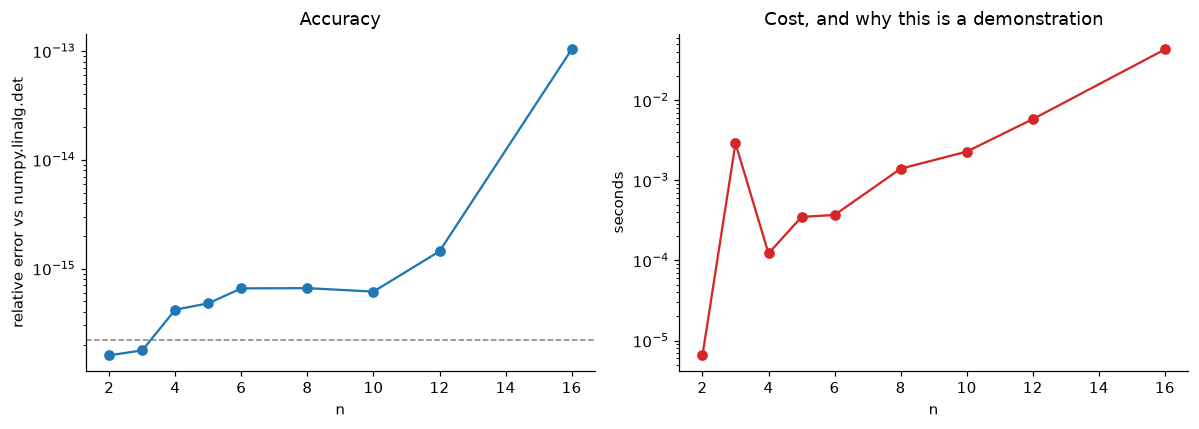

In [3]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(sizes, errors, marker="o"); left.set_yscale("log")
left.set_xlabel("n"); left.set_ylabel("relative error vs numpy.linalg.det")
left.set_title("Accuracy"); left.axhline(2.2e-16, ls="--", c="grey", lw=1)
right.plot(sizes, seconds, marker="o", color="#d62728"); right.set_yscale("log")
right.set_xlabel("n"); right.set_ylabel("seconds")
right.set_title("Cost, and why this is a demonstration")
plt.tight_layout(); plt.show()

## Where it refuses

The identity divides by the determinant of the leading block, so a singular
block is a property of the split rather than of the matrix. A row swap would fix
it. This implementation raises instead, so the limitation stays visible.

In [4]:
singular_leading_block = np.array([[0., 0., 1., 2.], [0., 0., 3., 4.],
                                   [1., 2., 0., 0.], [3., 5., 0., 0.]])
try:
    determinant(singular_leading_block)
except SingularLeadingBlock as error:
    print(error)
print(f"\nnumpy manages it: {np.linalg.det(singular_leading_block):.3f}")

the 2x2 leading block is singular, so the Schur identity cannot divide by its determinant

numpy manages it: 2.000
